In [1]:
import csv
from IPython.display import display
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各路径设定

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

# 种类数设定

In [3]:
NUM_CLASSES = 5

# 加载训练数据

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# 构建模型

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    # 第一层：加宽
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2), # 降低 Dropout
    
    # 第二层
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.1),
    
    # 第三层（可选，增加非线性表达）
    tf.keras.layers.Dense(16, activation='relu'),
    
    # 输出层
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                2752      
                                                                 
 batch_normalization (BatchN  (None, 64)               256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_1 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 32)                0

In [9]:
# 模型检查点回调函数
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 用于提前终止的回调函数
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# 模型编译
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 模型训练

In [11]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
25/35 [====================>.........] - ETA: 0s - loss: 1.7431 - accuracy: 0.3022 
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
35/35 [==============================] - 1s 10ms/step - loss: 1.6331 - accuracy: 0.3445 - val_loss: 1.4988 - val_accuracy: 0.3737
Epoch 2/1000
23/35 [==================>...........] - ETA: 0s - loss: 1.1525 - accuracy: 0.5516
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
35/35 [==============================] - 0s 4ms/step - loss: 1.1020 - accuracy: 0.5813 - val_loss: 1.3450 - val_accuracy: 0.6140
Epoch 3/1000
27/35 [======================>.......] - ETA: 0s - loss: 0.8348 - accuracy: 0.7202
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
35/35 [==============================] - 0s 4ms/step - loss: 0.8054 - accuracy: 0.7372 - val_loss: 1.1557 - val_accuracy: 0.7372
Epoch 4/1000
27/35 [======================>.......] - ETA: 0s - loss: 0.6024 - accuracy: 0.8284

In [12]:
# 模型评估
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

12/12 [==============================] - 0s 1ms/step - loss: 0.0147 - accuracy: 0.9945


In [13]:
# 加载已保存的模型
model = tf.keras.models.load_model(model_save_path)

In [14]:
# 预测测试
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 89ms/step
[6.2344284e-03 5.6095729e-07 9.8770909e-07 3.1776943e-03 9.9058634e-01]
4


# 混淆矩阵

46/46 [==============================] - 0s 889us/step


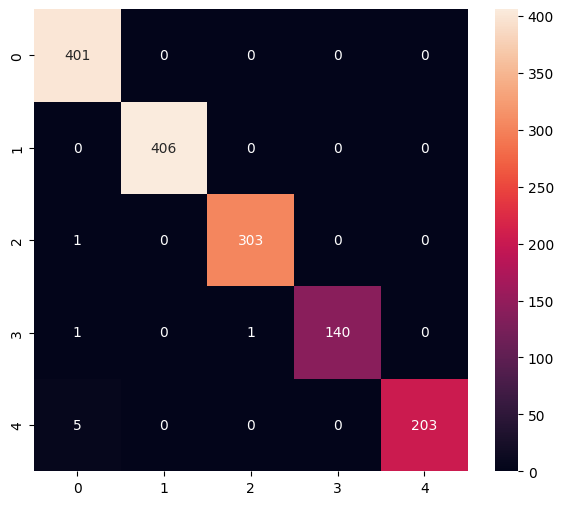

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       401
           1       1.00      1.00      1.00       406
           2       1.00      1.00      1.00       304
           3       1.00      0.99      0.99       142
           4       1.00      0.98      0.99       208

    accuracy                           0.99      1461
   macro avg       1.00      0.99      0.99      1461
weighted avg       0.99      0.99      0.99      1461



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# 转换为适用于 TensorFlow-Lite 的模型

In [16]:
# 保存为推理专用模型
model.save(model_save_path, include_optimizer=False)

In [17]:
# 模型转换（量化）
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\wzc\AppData\Local\Temp\tmpl3w3h9bn\assets


10760

# 推理测试

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [19]:
# 获取输入输出张量
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# 执行推理
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [22]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[6.3683465e-03 5.9261350e-07 9.6688507e-07 3.0386783e-03 9.9059147e-01]
4
